# Week 2 Assignment 1
## Netflix User Analytics
Name: Vanshika
Enrolment No: 21601012025

In [1]:
# importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

In [2]:
# creating the dataset with 750 users
np.random.seed(42)
n = 750

ages = np.random.randint(18, 65, n)
genders = np.random.choice(['Male', 'Female'], n)
sub_type = np.random.choice(['Basic', 'Premium', 'VIP'], n, p=[0.4, 0.4, 0.2])
watch_hrs = np.round(np.random.uniform(1, 40, n), 1)
devices = np.random.randint(1, 6, n)
genre = np.random.choice(['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Horror', 'Romance'], n)
ad_clicks = np.random.randint(0, 50, n)

base = {'Basic': 199, 'Premium': 499, 'VIP': 999}
spend = np.array([base[s] + np.random.randint(-30, 30) for s in sub_type])

prob = (
    0.3*(watch_hrs/40) +
    0.3*(spend/999) +
    0.2*(devices/5) +
    0.2*np.random.rand(n)
)
renewed = np.where(prob > 0.5, 'Yes', 'No')

df = pd.DataFrame({
    'UserID': range(1, n+1),
    'Age': ages,
    'Gender': genders,
    'SubscriptionType': sub_type,
    'WatchHoursPerWeek': watch_hrs,
    'DevicesUsed': devices,
    'FavoriteGenre': genre,
    'AdClicks': ad_clicks,
    'MonthlySpend': spend,
    'SubscriptionRenewed': renewed
})

## Part A - Dataset Understanding

In [3]:
# Q1 - first 5 rows
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1,56,Female,Basic,21.1,5,Drama,39,176,Yes
1,2,46,Male,Premium,36.9,2,Drama,42,473,Yes
2,3,32,Male,Premium,20.4,5,Comedy,21,494,Yes
3,4,60,Male,Premium,39.7,3,Action,19,484,Yes
4,5,25,Female,Premium,34.2,3,Sci-Fi,7,504,Yes


In [4]:
# Q2 - rows and columns
print('Shape of dataset:', df.shape)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Shape of dataset: (750, 10)
Rows: 750
Columns: 10


In [5]:
# Q3 - column names
print(df.columns.tolist())

['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


In [6]:
# Q4 - numerical and categorical features
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Numerical:', num_cols)
print('Categorical:', cat_cols)

Numerical: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [7]:
# Q5 - checking missing values
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


## Part B - Exploratory Data Analysis

In [8]:
# Q6 - average age
print('Average Age:', df['Age'].mean())

Average Age: 41.221333333333334


In [9]:
# Q7 - average watch hours per week
print('Avg Watch Hours/Week:', df['WatchHoursPerWeek'].mean())

Avg Watch Hours/Week: 20.450266666666668


In [10]:
# Q8 - average monthly spending
print('Avg Monthly Spend: Rs', df['MonthlySpend'].mean())

Avg Monthly Spend: Rs 484.908


SubscriptionType
Premium    305
Basic      291
VIP        154
Name: count, dtype: int64


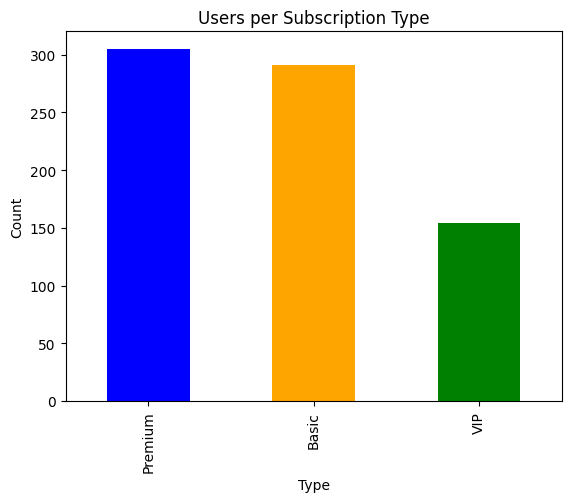

In [11]:
# Q9 - users in each subscription type
print(df['SubscriptionType'].value_counts())

df['SubscriptionType'].value_counts().plot(kind='bar', color=['blue','orange','green'])
plt.title('Users per Subscription Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

SubscriptionRenewed
Yes    53.466667
No     46.533333
Name: proportion, dtype: float64


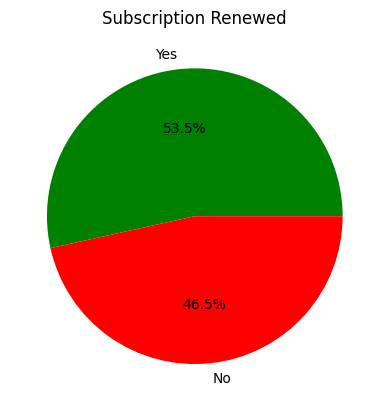

In [12]:
# Q10 - percentage of users who renewed
renew_pct = df['SubscriptionRenewed'].value_counts(normalize=True)*100
print(renew_pct)

plt.pie(df['SubscriptionRenewed'].value_counts(),
        labels=['Yes','No'], autopct='%1.1f%%', colors=['green','red'])
plt.title('Subscription Renewed')
plt.show()

## Part C - Data Preparation

In [13]:
# Q11 - label encoding categorical columns
df2 = df.copy()
le = LabelEncoder()

for col in ['Gender','SubscriptionType','FavoriteGenre','SubscriptionRenewed']:
    df2[col] = le.fit_transform(df2[col])

df2.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1,56,0,0,21.1,5,2,39,176,1
1,2,46,1,1,36.9,2,2,42,473,1
2,3,32,1,1,20.4,5,1,21,494,1
3,4,60,1,1,39.7,3,0,19,484,1
4,5,25,0,1,34.2,3,5,7,504,1


In [14]:
# Q12 - defining X and y
X = df2[['Age','Gender','SubscriptionType','WatchHoursPerWeek','DevicesUsed','FavoriteGenre','AdClicks','MonthlySpend']]
y = df2['SubscriptionRenewed']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (750, 8)
y shape: (750,)


In [15]:
# Q13 - train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 600
Test size: 150


## Part D - Decision Tree Classification

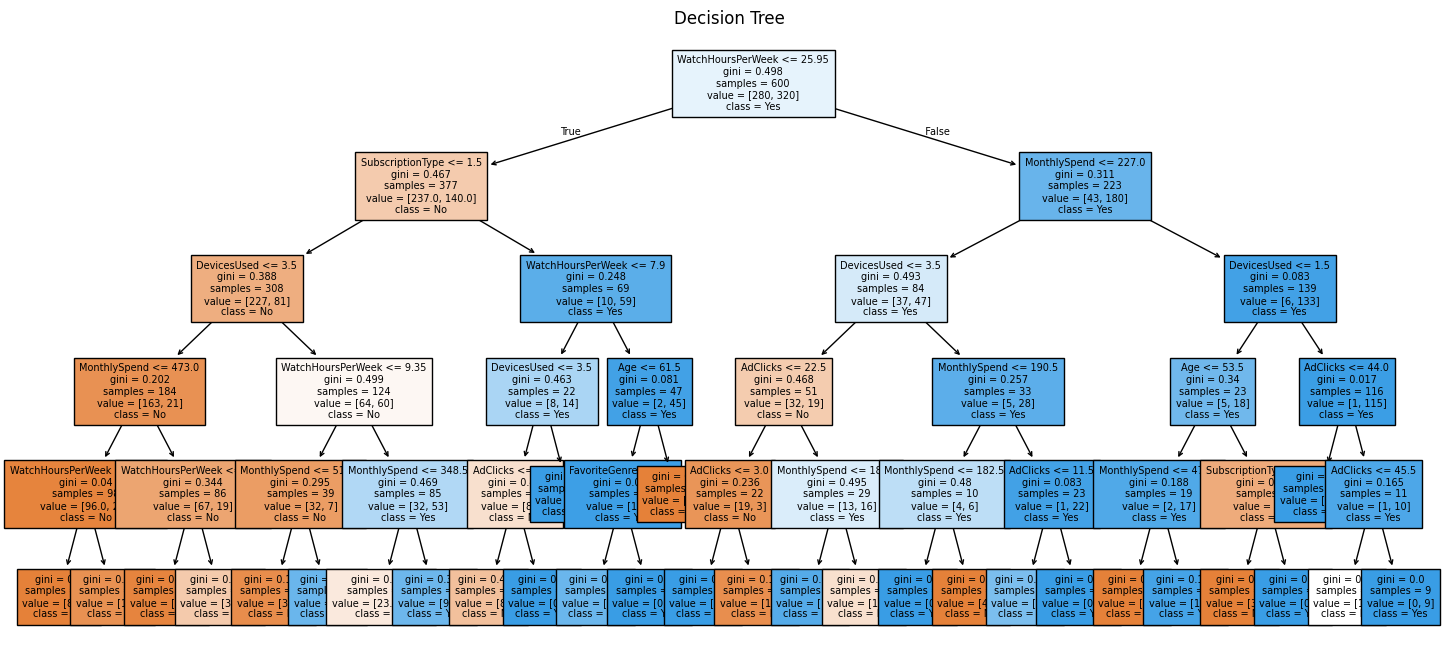

In [16]:
# Q14 - training decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(18,8))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True, fontsize=7)
plt.title('Decision Tree')
plt.show()

In [17]:
# Q15 - accuracy
y_pred_dt = dt.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt)*100, '%')

Decision Tree Accuracy: 76.66666666666667 %


[[56 13]
 [22 59]]


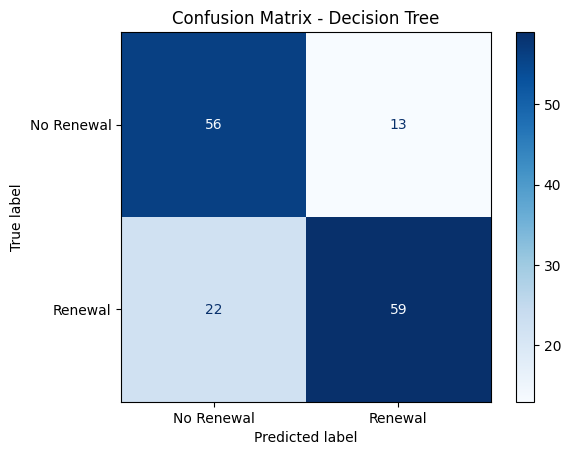

In [18]:
# Q16 - confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)
ConfusionMatrixDisplay(cm, display_labels=['No Renewal','Renewal']).plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

## Part E - KNN

In [19]:
# Q17 - KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print('KNN Accuracy:', accuracy_score(y_test, y_pred_knn)*100, '%')

KNN Accuracy: 76.66666666666667 %


Decision Tree: 76.66666666666667 %
KNN: 76.66666666666667 %


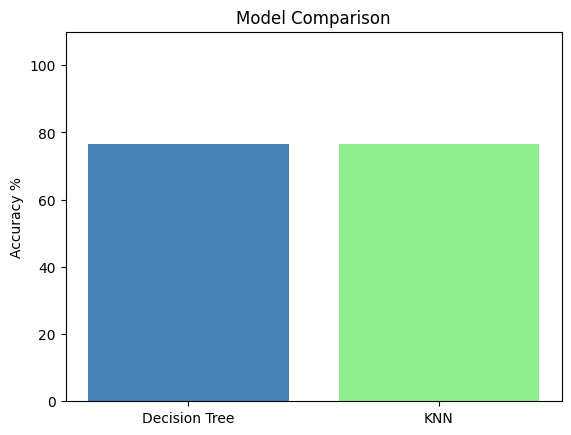

In [20]:
# Q18 - comparing both models
dt_acc = accuracy_score(y_test, y_pred_dt)*100
knn_acc = accuracy_score(y_test, y_pred_knn)*100

print('Decision Tree:', dt_acc, '%')
print('KNN:', knn_acc, '%')

plt.bar(['Decision Tree', 'KNN'], [dt_acc, knn_acc], color=['steelblue','lightgreen'])
plt.ylabel('Accuracy %')
plt.title('Model Comparison')
plt.ylim(0, 110)
plt.show()

## Part F - Linear Regression

MSE: 2723.380886202285
R2 Score: 0.9679295022704412


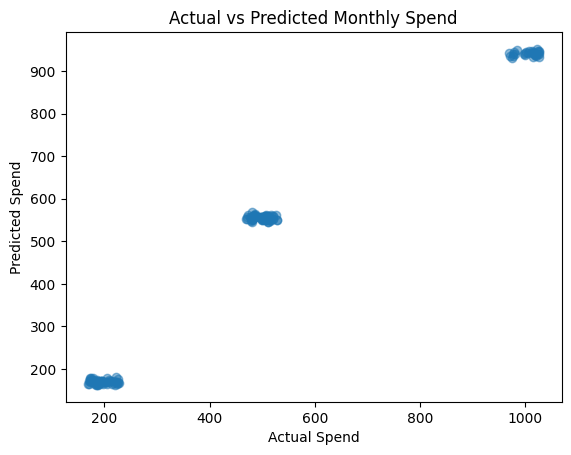

In [21]:
# Q19 - linear regression to predict monthly spend
X_reg = df2[['Age','Gender','SubscriptionType','WatchHoursPerWeek','DevicesUsed','FavoriteGenre','AdClicks']]
y_reg = df2['MonthlySpend']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(Xr_train, yr_train)
y_pred_lr = lr.predict(Xr_test)

print('MSE:', mean_squared_error(yr_test, y_pred_lr))
print('R2 Score:', r2_score(yr_test, y_pred_lr))

plt.scatter(yr_test, y_pred_lr, alpha=0.5)
plt.xlabel('Actual Spend')
plt.ylabel('Predicted Spend')
plt.title('Actual vs Predicted Monthly Spend')
plt.show()

In [ ]:
# Q20 - predicting for a new user
# age=25, female=0, premium=1, 20hrs, 2 devices, drama=1, 5 ad clicks
new_user = [[25, 0, 1, 20.0, 2, 1, 5]]
pred = lr.predict(new_user)
print('Predicted Monthly Spend for new user: Rs', round(pred[0], 2))

## Business Reflection Questions

**Q1. Which factors appear to influence subscription renewal the most?**  
WatchHoursPerWeek, MonthlySpend and DevicesUsed seem to influence renewal the most. Users who watch more and spend more are more likely to renew.

**Q2. Why is subscription renewal a classification problem?**  
Because the output is either Yes or No which are discrete categories, so we use classification algorithms like Decision Tree and KNN.

**Q3. Why is monthly spending a regression problem?**  
Because the output is a continuous number like 199, 499, etc. so we use regression to predict it.

**Q4. Which algorithm performed better for renewal prediction?**  
Based on accuracy scores above, Decision Tree performed better than KNN as it can handle non-linear patterns better.

**Q5. How could the platform use these predictions to improve customer retention?**  
Netflix can identify users who are likely to not renew and send them special offers or discounts. They can also recommend more content to users with low watch hours to increase engagement.